In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('advertising_Dataset.csv')
data

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [7]:
data = data.drop('Unnamed: 0',axis=1)
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [8]:
print(f'دیتاست شامل {data.shape[0]} ردیف و {data.shape[1]} ستون میباشد')

دیتاست شامل 200 ردیف و 4 ستون میباشد


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [11]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [12]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [14]:
summary_table = pd.DataFrame({
    'mean' : data.mean(numeric_only=True),
    'median': data.median(numeric_only=True),
    'variance':data.var(numeric_only=True),
    'std': data.std(numeric_only=True),
    "Min": data.min(numeric_only=True),
    "Max": data.max(numeric_only=True)
})

summary_table

,mean,median,variance,std,Min,Max
TV,147.0425,149.75,7370.949893,85.854236,0.7,296.4
Radio,23.2640,22.90,220.427743,14.846809,0.0,49.6
Newspaper,30.5540,25.75,474.308326,21.778621,0.3,114.0
Sales,14.0225,12.90,27.221853,5.217457,1.6,27.0


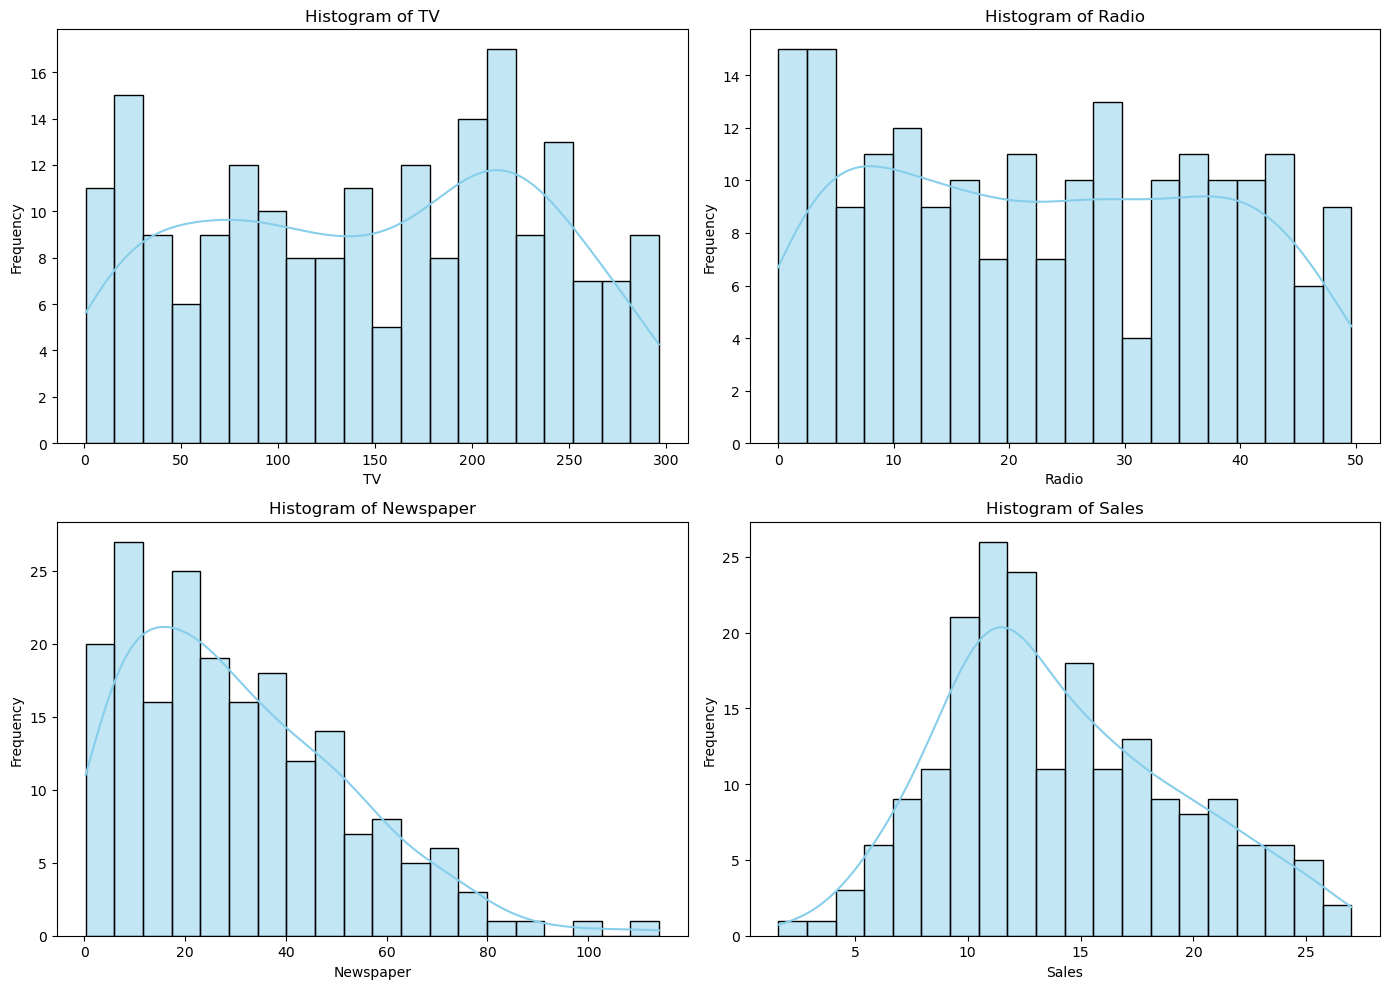

In [18]:
cols = ['TV', 'Radio', 'Newspaper', 'Sales']

plt.figure(figsize=(14, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[col], bins=20, kde=True, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


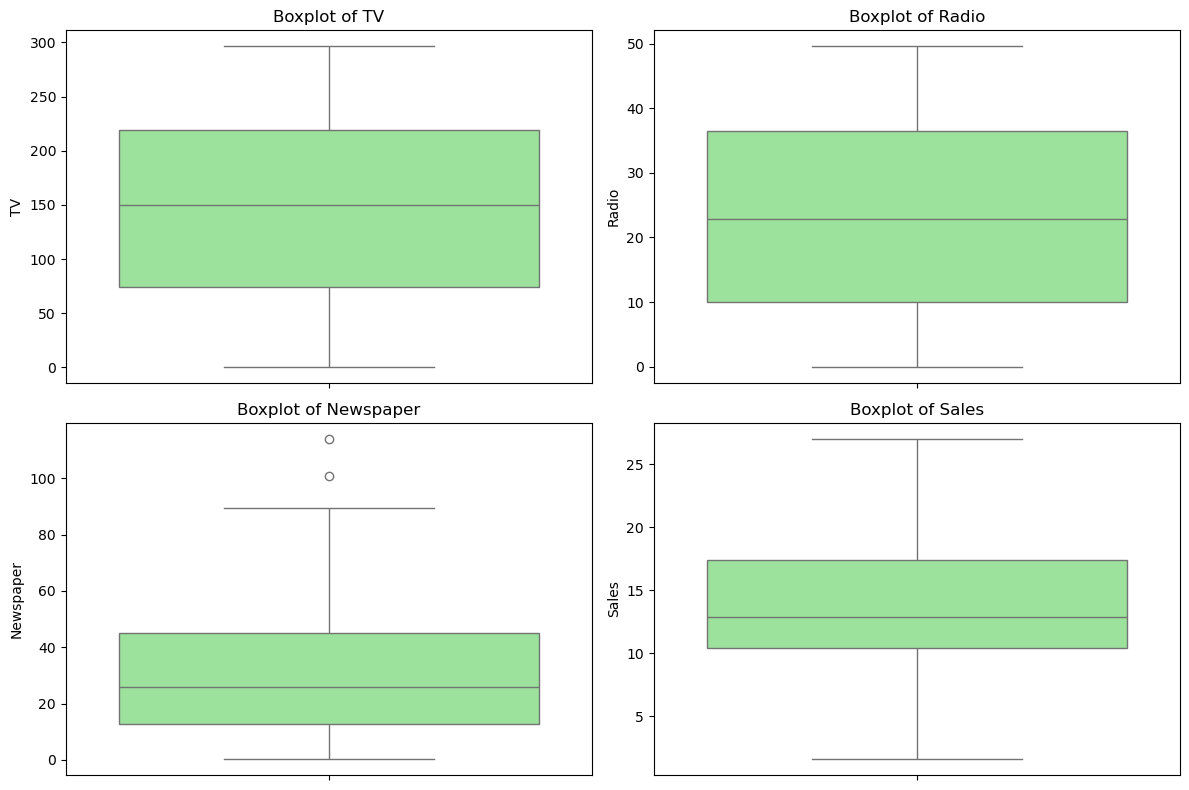

In [19]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=data[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


In [24]:
X = data[['TV', 'Radio', 'Newspaper']].values

# نرمال‌سازی 
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

#  محاسبه ماتریس کوواریانس
# فرمول: C = (X^T * X) / (n-1)
n = X_scaled.shape[0]
cov_matrix = np.dot(X_scaled.T, X_scaled) / (n - 1)

print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[1.00502513 0.05508408 0.05693254]
 [0.05508408 1.00502513 0.35588317]
 [0.05693254 0.35588317 1.00502513]]


In [25]:
# اجرای SVD
U, S, Vt = np.linalg.svd(X_scaled)

eigenvalues = (S**2) / (n - 1)
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

print(f"Explained Variance Ratio: {explained_variance_ratio}")


Explained Variance Ratio: [0.45695084 0.32775205 0.21529712]


In [27]:
X_reg = np.column_stack([np.ones(X.shape[0]), X])
y_reg = data['Sales'].values

beta = np.linalg.pinv(X_reg).dot(y_reg)

print(f"Coefficients (Intercept, TV, Radio, Newspaper): {beta}")


Coefficients (Intercept, TV, Radio, Newspaper): [ 2.93888937e+00  4.57646455e-02  1.88530017e-01 -1.03749304e-03]


In [32]:
from scipy import stats

# ۱. محاسبه پیش‌بینی‌ها و خطا
predictions = X_reg.dot(beta)
residuals = y_reg - predictions

# ۲. واریانس خطاها
RSS = np.sum(residuals**2)
df_resid = X_reg.shape[0] - X_reg.shape[1]
sigma_squared = RSS / df_resid

# ۳. ماتریس واریانس-کوواریانس ضرایب
var_beta = sigma_squared * np.linalg.inv(X_reg.T.dot(X_reg))
se_beta = np.sqrt(np.diag(var_beta))

# ۴. محاسبه t-statistic و p-value
t_stats = beta / se_beta
p_values = [2 * (1 - stats.t.cdf(np.abs(t), df_resid)) for t in t_stats]

print(f"T-stats: {t_stats}")
print(f"P-values: {p_values}")


T-stats: [ 9.42228844 32.80862443 21.89349606 -0.17671459]
P-values: [0.0, 0.0, 0.0, 0.8599150500805934]


In [33]:
# ۱. مشخص کردن موفقیت‌ها (Successes)
median_sales = data['Sales'].median()
high_sales_mask = data['Sales'] > median_sales
n_high_sales = np.sum(high_sales_mask)
n_total = len(data)

# ۲. پارامترهای پیشین
alpha_prior = 1
beta_prior = 1

# ۳. به‌روزرسانی بیزی (Posterior)
# در توزیع بتا، پسین به سادگی با جمع زدن تعداد موفقیت‌ها و شکست‌ها به دست می‌آید
alpha_post = alpha_prior + n_high_sales
beta_post = beta_prior + (n_total - n_high_sales)

# ۴. برآورد میانگین پسین
expected_theta = alpha_post / (alpha_post + beta_post)

print(f"Total High Sales: {n_high_sales} out of {n_total}")
print(f"Posterior Mean (Probability of High Sales): {expected_theta:.4f}")


Total High Sales: 98 out of 200
Posterior Mean (Probability of High Sales): 0.4901


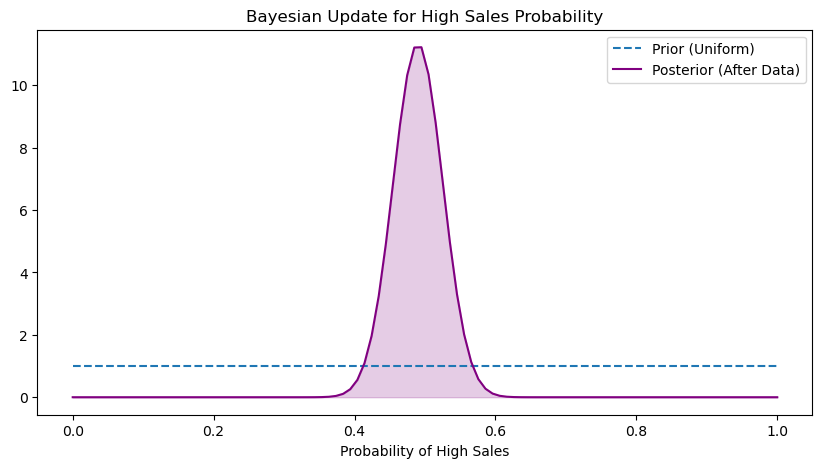

In [34]:
x = np.linspace(0, 1, 100)
y_prior = stats.beta.pdf(x, alpha_prior, beta_prior)
y_post = stats.beta.pdf(x, alpha_post, beta_post)

plt.figure(figsize=(10, 5))
plt.plot(x, y_prior, label='Prior (Uniform)', linestyle='--')
plt.plot(x, y_post, label='Posterior (After Data)', color='purple')
plt.fill_between(x, 0, y_post, color='purple', alpha=0.2)
plt.title("Bayesian Update for High Sales Probability")
plt.xlabel("Probability of High Sales")
plt.legend()
plt.show()
